<a href="https://colab.research.google.com/github/Brunoxue/hsi_examples/blob/main/sklearn_classification_salinas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://huggingface.co/datasets/danaroth/salinas

fatal: destination path 'salinas' already exists and is not an empty directory.


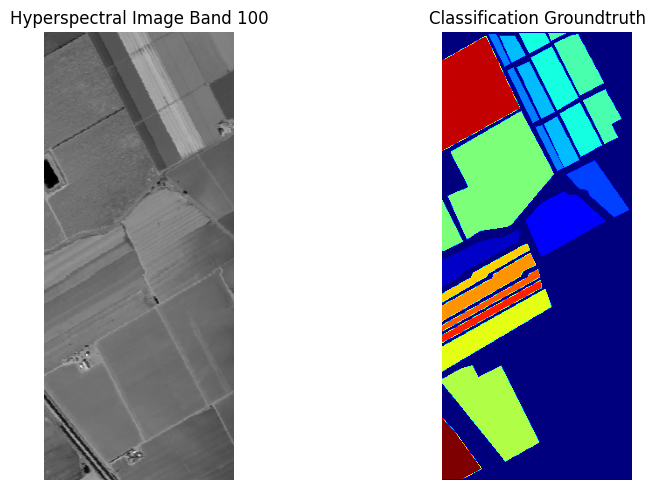

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

# Load the hyperspectral data
hsi = loadmat('salinas/Salinas.mat')['salinas'].astype(float)
GT = loadmat('salinas/Salinas_gt.mat')['salinas_gt'].astype(float)

water_absorption_bands = np.append(np.arange(108,113),(np.arange(154, 167)), 224)
hsi = np.delete(hsi,water_absorption_bands-1,axis=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
axs[0].imshow(hsi[:, :, 100], cmap='gray')
axs[0].axis('off')
axs[0].set_title('Hyperspectral Image Band 100')

# Plot the spectrum
axs[1].imshow(GT, cmap='jet')
axs[1].axis('off')
axs[1].set_title('Classification Groundtruth')

plt.show()

In [ ]:
# Generate Samples for Training and Testing
(x,y,L)=hsi.shape
N=x*y

hsi=np.reshape(hsi,(N,L))
GT=np.reshape(GT,(N,))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(hsi[GT!=0,:], GT[GT!=0], train_size = 0.02, random_state=0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

# Evaluation of classifiers
def classification_evaluation(y_test, y_predict, n_class=16):
  recall=recall_score(y_test, y_predict, average=None) * 100
  precision=precision_score(y_test, y_predict, average=None) * 100
  OA=accuracy_score(y_test, y_predict) * 100
  AA=recall_score(y_test, y_predict, average="macro") * 100

  # Create a dataframe to display the metrics
  metrics_df = pd.DataFrame({
      'Recall (%)': recall,
      'Precision (%)': precision,
      '# of Test Samples': [np.sum(y_test==i+1) for i in range(n_class)],
      '# of Train Samples': [np.sum(y_train==i+1) for i in range(n_class)],
  })

  metrics_df.reset_index()
  metrics_df.index = metrics_df.index + 1

  pd.options.display.precision = 2

  print(metrics_df.to_string())

  metrics_image_df = pd.DataFrame({
      'values': [OA, AA],
      }, index=(['OA(%)','AA(%)']))

  print(metrics_image_df.to_string(header=False))
  return {"recall":recall, "precision":precision, "OA":OA, "AA":AA}


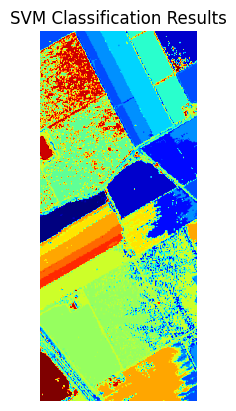

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1        98.57         100.00               1960                  49
2        99.86          99.24               3654                  72
3        99.12          93.87               1931                  45
4        99.26          96.98               1360                  34
5        97.32          98.30               2615                  63
6        99.74          99.97               3879                  80
7        99.37          99.83               3503                  76
8        83.01          76.80              11049                 222
9        98.85          99.19               6082                 121
10       93.53          94.26               3214                  64
11       91.32          95.41               1048                  20
12       99.47          97.10               1883                  44
13       98.89          94.30                903                  13
14       91.68          97.36     

In [ ]:
# Support Vector Machine Classification
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svc', SVC())
    ])

param_svm = [
    {'svc__C': 10.0**np.arange(-2,5,1), 'svc__gamma': 10.0**np.arange(-3,3,1), 'svc__kernel': ['rbf']},
    ]

clf = GridSearchCV(pipe_svm, param_svm)
clf.fit(X_train, y_train)

y_predict_svm = clf.best_estimator_.predict(X_test)

results_svm = clf.best_estimator_.predict(hsi)
results_svm = np.reshape(results_svm,(x,y))

plt.figure()
plt.imshow(results_svm, cmap='jet')
plt.axis('off')
plt.title('SVM Classification Results')
plt.show()

performance_svm = classification_evaluation(y_test, y_predict_svm)

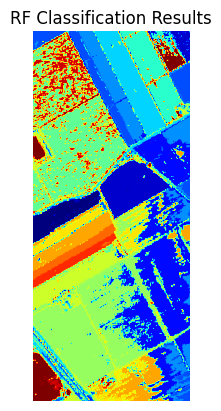

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1        96.63          99.89               1960                  49
2        99.78          98.22               3654                  72
3        97.77          88.43               1931                  45
4        97.50          96.65               1360                  34
5        95.98          98.16               2615                  63
6        99.07          99.87               3879                  80
7        97.52          99.10               3503                  76
8        86.45          71.63              11049                 222
9        98.73          97.83               6082                 121
10       87.43          89.32               3214                  64
11       89.79          94.01               1048                  20
12       98.04          95.65               1883                  44
13       99.00          94.11                903                  13
14       91.97          92.15     

In [ ]:
# Random Forest Classification
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(n_estimators=500, oob_score=True))
    ])

pipe_rf.fit(X_train, y_train)
y_predict_rf = pipe_rf.predict(X_test)

results_rf = pipe_rf.predict(hsi)
results_rf = np.reshape(results_rf,(x,y))

plt.figure()
plt.imshow(results_rf, cmap='jet')
plt.axis('off')
plt.title('RF Classification Results')
plt.show()

performance_rf = classification_evaluation(y_test, y_predict_rf)

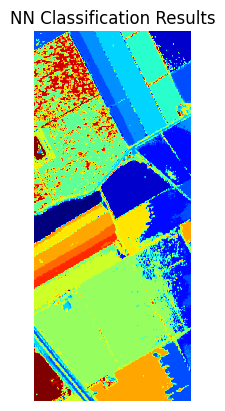

    Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1        97.60         100.00               1960                  49
2        99.89          98.73               3654                  72
3        91.30          94.28               1931                  45
4        99.34          98.61               1360                  34
5        98.36          96.55               2615                  63
6        99.87          99.95               3879                  80
7        99.14          99.88               3503                  76
8        82.22          72.74              11049                 222
9        99.29          99.21               6082                 121
10       87.99          88.76               3214                  64
11       86.74          89.82               1048                  20
12       98.99          93.81               1883                  44
13       99.00          93.12                903                  13
14       91.68          96.87     

In [ ]:
# Neural Network
from sklearn.neural_network import MLPClassifier

pipe_nn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('nn', MLPClassifier(solver='adam', hidden_layer_sizes=(20), random_state=1, batch_size=20, max_iter=1000, learning_rate_init=0.001))
    ])

pipe_nn.fit(X_train, y_train)
y_predict_nn = pipe_nn.predict(X_test)

results_nn = pipe_nn.predict(hsi)
results_nn = np.reshape(results_nn,(x,y))

plt.figure()
plt.imshow(results_nn, cmap='jet')
plt.axis('off')
plt.title('NN Classification Results')
plt.show()

performance_svm = classification_evaluation(y_test, y_predict_nn)